# Практична робота №11
## Числові характеристики випадкової величини; закон великих чисел і ЦГТ симуляцією
**Виконав:** Хрустовський Павло  
**Група:** ІТ-42  
**Варіант:** 6 (Чернігів, λ = 0.22)  
**№ у журналі:** 26


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(6)

lam = 0.22
expected_value = 1 / lam
print(f"Теоретичне матсподівання E[X] = {expected_value:.3f} хв")


Теоретичне матсподівання E[X] = 4.545 хв


In [2]:
sample_sizes = [5, 50, 500, 20000]
for n in sample_sizes:
    sample = rng.exponential(scale=1/lam, size=n)
    s_mean = sample.mean()
    err = abs(s_mean - expected_value)
    print(f"n = {n:5d}: вибіркове середнє = {s_mean:.3f}, відхилення від E[X] = {err:.3f}")


n =     5: вибіркове середнє = 2.498, відхилення від E[X] = 2.047
n =    50: вибіркове середнє = 4.549, відхилення від E[X] = 0.003
n =   500: вибіркове середнє = 4.453, відхилення від E[X] = 0.093
n = 20000: вибіркове середнє = 4.515, відхилення від E[X] = 0.031


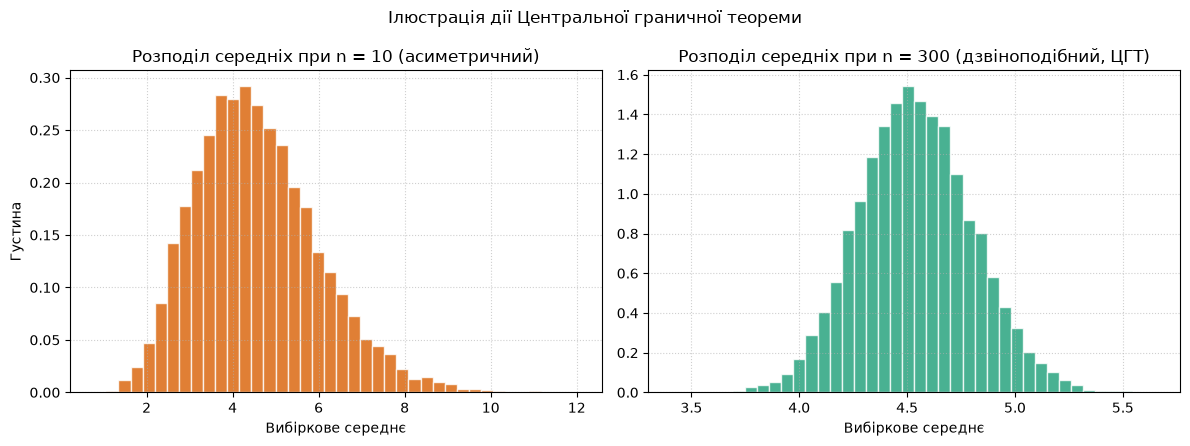

In [3]:
simulations = 10000
means_10 = rng.exponential(scale=1/lam, size=(simulations, 10)).mean(axis=1)
means_300 = rng.exponential(scale=1/lam, size=(simulations, 300)).mean(axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.hist(means_10, bins=40, density=True, color="#d95f02", alpha=0.8, edgecolor="white")
ax1.set_title("Розподіл середніх при n = 10 (асиметричний)")
ax1.set_xlabel("Вибіркове середнє")
ax1.set_ylabel("Густина")
ax1.grid(True, linestyle=":", alpha=0.6)

ax2.hist(means_300, bins=40, density=True, color="#1b9e77", alpha=0.8, edgecolor="white")
ax2.set_title("Розподіл середніх при n = 300 (дзвіноподібний, ЦГТ)")
ax2.set_xlabel("Вибіркове середнє")
ax2.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Ілюстрація дії Центральної граничної теореми")
plt.tight_layout()
plt.show()


In [4]:
sizes = [10, 30, 100, 300]
print("  n  | Теоретична SE | Емпірична std(x̄)")
print("-" * 38)
for n in sizes:
    se_theory = expected_value / np.sqrt(n)
    sample_means = rng.exponential(scale=1/lam, size=(simulations, n)).mean(axis=1)
    se_emp = sample_means.std()
    print(f"{n:4d} |    {se_theory:.4f}     |     {se_emp:.4f}")


  n  | Теоретична SE | Емпірична std(x̄)
--------------------------------------
  10 |    1.4374     |     1.4364
  30 |    0.8299     |     0.8386
 100 |    0.4545     |     0.4610
 300 |    0.2624     |     0.2638


In [5]:
se_25 = expected_value / np.sqrt(25)
se_100 = expected_value / np.sqrt(100)
print(f"Стандартна похибка для n=25:  {se_25:.4f}")
print(f"Стандартна похибка для n=100: {se_100:.4f}")
print(f"Коефіцієнт зменшення похибки (SE_25 / SE_100): {se_25 / se_100:.2f}")


Стандартна похибка для n=25:  0.9091
Стандартна похибка для n=100: 0.4545
Коефіцієнт зменшення похибки (SE_25 / SE_100): 2.00


### Відповіді на контрольні запитання

1. **У чому полягає принципова відмінність між Законом великих чисел (ЗВЧ) та Центральною граничною теоремою (ЦГТ)?**  
   - **Закон великих чисел** гарантує асимптотичну збіжність вибіркового середнього до теоретичного математичного сподівання ($ \bar{X}_n \xrightarrow{P} \mu $ при $n \to \infty$). Він визначає границю самого показника (точки).
   - **Центральна гранична теорема** описує *форму розподілу* та розкид цього вибіркового середнього навколо $\mu$, доводячи, що нормована сума (або середнє) при зростанні $n$ наближається до нормального закону розподілу, навіть якщо вихідна величина мала зовсім інший розподіл.

2. **Чому для симуляції обрано саме експоненційний розподіл, а не нормальний?**  
   - Експоненційний розподіл є різко скошеним (асиметричним) з високою густиною біля нуля та довгим "хвостом" праворуч. Використання саме такого розподілу унаочнює трансформацію форми: при малих $n$ розподіл середніх залишається скошеним, але при зростанні $n$ він вирівнюється і стає симетричним нормальним дзвоном. Для нормального розподілу середнє завжди нормальне при будь-якому $n$, тому ефект ЦГТ не був би настільки очевидним.

3. **Чому стандартна похибка спадає пропорційно $1/\sqrt{n}$, а не $1/n$, і які це має наслідки?**  
   - Дисперсія середнього значення незалежних величин дорівнює $\operatorname{Var}(\bar{X}) = \frac{\sigma^2}{n}$, отже стандартне відхилення середнього (стандартна похибка) становить $SE = \frac{\sigma}{\sqrt{n}}$.
   - Практичний наслідок: щоб підвищити точність оцінки (зменшити похибку) вдвічі, розмір вибірки необхідно збільшити вчетверо ($2^2 = 4$). Для зменшення похибки в 10 разів вибірку слід збільшити у 100 разів.
